In [453]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import warnings
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import scale
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error ,r2_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn import model_selection
from sklearn.linear_model import Ridge ,Lasso,ElasticNet
import statsmodels.api as sm
from warnings import filterwarnings
filterwarnings('ignore')
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

print("Burada kütüphaneleri tanımladık")

Burada kütüphaneleri tanımladık


In [454]:
df=pd.read_csv("veriset.csv" , sep=";", encoding= "utf-8-sig")

print("Burada veri okuma islemini gerceklestiriyoruz csv'den okunuyor ")

Burada veri okuma islemini gerceklestiriyoruz csv'den okunuyor 


In [455]:
df.head()

,Ni,Cr,Fe,Co,Mo,Nb,Ti,Al,Mn,Si,...,Temperature (ºC),0.2% Proof Stress (MPa),Fracture Stress (MPa),Young's Modulus (GPa),Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20
0,67.0,22,5,0,0,1,2.5,0.5,1,0.5,...,920.0,89.27,332.99,137.50,NaN,NaN,NaN,NaN,NaN,NaN
1,67.0,22,5,0,0,1,2.5,0.5,1,0.5,...,900.0,165.08,551.78,139.74,NaN,NaN,NaN,NaN,NaN,NaN
2,67.0,22,5,0,0,1,2.5,0.5,1,0.5,...,880.0,218.35,729.71,141.92,NaN,NaN,NaN,NaN,NaN,NaN
3,67.0,22,5,0,0,1,2.5,0.5,1,0.5,...,860.0,266.94,904.87,144.06,NaN,NaN,NaN,NaN,NaN,NaN
4,67.0,22,5,0,0,1,2.5,0.5,1,0.5,...,840.0,315.27,1024.14,146.16,NaN,NaN,NaN,NaN,NaN,NaN


In [457]:
df_cleaned = df.dropna(axis=1, how="all")

print("\nBoş sütunlar kaldırıldıktan sonra:")
print(df_cleaned)


Boş sütunlar kaldırıldıktan sonra:
       Ni  Cr  Fe  Co  Mo  Nb   Ti   Al  Mn   Si   Cu  Temperature (ºC)  \
0    67.0  22   5   0   0   1  2.5  0.5   1  0.5  0.5             920.0   
1    67.0  22   5   0   0   1  2.5  0.5   1  0.5  0.5             900.0   
2    67.0  22   5   0   0   1  2.5  0.5   1  0.5  0.5             880.0   
3    67.0  22   5   0   0   1  2.5  0.5   1  0.5  0.5             860.0   
4    67.0  22   5   0   0   1  2.5  0.5   1  0.5  0.5             840.0   
..    ...  ..  ..  ..  ..  ..  ...  ...  ..  ...  ...               ...   
995  64.0  14   9   0   3   5  2.5  0.5   1  0.5  0.5             620.0   
996  64.0  14   9   0   3   5  2.5  0.5   1  0.5  0.5             600.0   
997  64.0  14   9   0   3   5  2.5  0.5   1  0.5  0.5             580.0   
998  64.0  14   9   0   3   5  2.5  0.5   1  0.5  0.5             560.0   
999  64.0  14   9   0   3   5  2.5  0.5   1  0.5  0.5             540.0   

     0.2% Proof Stress (MPa)  Fracture Stress (MPa)  Young's Mo

In [458]:
df.describe()

,Ni,Cr,Fe,Co,Mo,Nb,Ti,Al,Mn,Si,...,Temperature (ºC),0.2% Proof Stress (MPa),Fracture Stress (MPa),Young's Modulus (GPa),Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000,1000.000000,1000.000000,1000.0,1000.0,1000.0,...,1000.000000,1000.000000,1000.000000,1000.000000,0.0,0.0,0.0,0.0,0.0,0.0
mean,69.020000,14.960000,6.800000,0.740000,1.400,2.680000,1.900000,0.5,1.0,0.5,...,730.000000,509.409710,1025.211170,158.036280,NaN,NaN,NaN,NaN,NaN,NaN
std,3.775428,2.600993,1.970757,0.912816,1.429,1.975222,0.735215,0.0,0.0,0.0,...,115.383332,336.752151,441.214969,10.350749,NaN,NaN,NaN,NaN,NaN,NaN
min,54.000000,14.000000,5.000000,0.000000,0.000,1.000000,1.000000,0.5,1.0,0.5,...,540.000000,30.170000,169.670000,135.110000,NaN,NaN,NaN,NaN,NaN,NaN
25%,67.000000,14.000000,5.000000,0.000000,0.000,1.000000,1.000000,0.5,1.0,0.5,...,635.000000,208.340000,679.512500,149.112500,NaN,NaN,NaN,NaN,NaN,NaN
50%,69.250000,14.000000,7.000000,0.000000,1.000,1.000000,2.500000,0.5,1.0,0.5,...,730.000000,464.290000,1171.810000,159.040000,NaN,NaN,NaN,NaN,NaN,NaN
75%,71.500000,14.000000,9.000000,2.000000,3.000,5.000000,2.500000,0.5,1.0,0.5,...,825.000000,768.945000,1378.480000,166.947500,NaN,NaN,NaN,NaN,NaN,NaN
max,76.500000,22.000000,15.000000,2.000000,3.000,5.000000,2.500000,0.5,1.0,0.5,...,920.000000,1123.120000,1637.380000,176.470000,NaN,NaN,NaN,NaN,NaN,NaN


In [459]:
df.isnull()

,Ni,Cr,Fe,Co,Mo,Nb,Ti,Al,Mn,Si,...,Temperature (ºC),0.2% Proof Stress (MPa),Fracture Stress (MPa),Young's Modulus (GPa),Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,True,True,True,True,True
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,True,True,True,True,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,True,True,True,True,True
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,True,True,True,True,True
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,True,True,True,True,True
996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,True,True,True,True,True
997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,True,True,True,True,True
998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,True,True,True,True,True


In [489]:
df_cleaned = df.dropna(axis=1, how="all")

print("\nBoş sütunlar kaldırıldıktan sonra:")
print(df_cleaned)


Boş sütunlar kaldırıldıktan sonra:
       Ni  Cr  Fe  Co  Mo  Nb   Ti   Al  Mn   Si   Cu  Temperature (ºC)  \
0    67.0  22   5   0   0   1  2.5  0.5   1  0.5  0.5             920.0   
1    67.0  22   5   0   0   1  2.5  0.5   1  0.5  0.5             900.0   
2    67.0  22   5   0   0   1  2.5  0.5   1  0.5  0.5             880.0   
3    67.0  22   5   0   0   1  2.5  0.5   1  0.5  0.5             860.0   
4    67.0  22   5   0   0   1  2.5  0.5   1  0.5  0.5             840.0   
..    ...  ..  ..  ..  ..  ..  ...  ...  ..  ...  ...               ...   
995  64.0  14   9   0   3   5  2.5  0.5   1  0.5  0.5             620.0   
996  64.0  14   9   0   3   5  2.5  0.5   1  0.5  0.5             600.0   
997  64.0  14   9   0   3   5  2.5  0.5   1  0.5  0.5             580.0   
998  64.0  14   9   0   3   5  2.5  0.5   1  0.5  0.5             560.0   
999  64.0  14   9   0   3   5  2.5  0.5   1  0.5  0.5             540.0   

     0.2% Proof Stress (MPa)  Fracture Stress (MPa)  Young's Mo

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0, 0.0, '0.0'),
  Text(0, 0.2, '0.2'),
  Text(0, 0.4, '0.4'),
  Text(0, 0.6000000000000001, '0.6'),
  Text(0, 0.8, '0.8'),
  Text(0, 1.0, '1.0')])

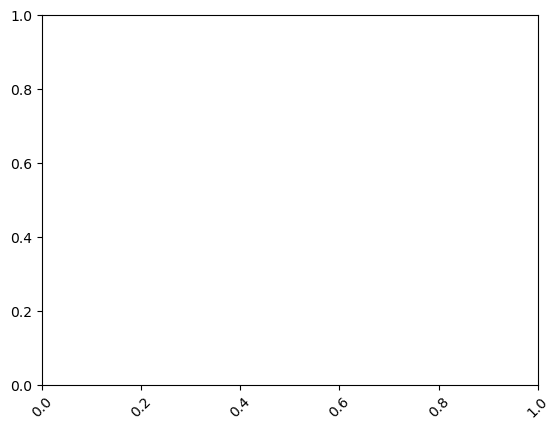

In [504]:
plt.xticks(rotation=45)
plt.yticks(rotation=0)

In [506]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

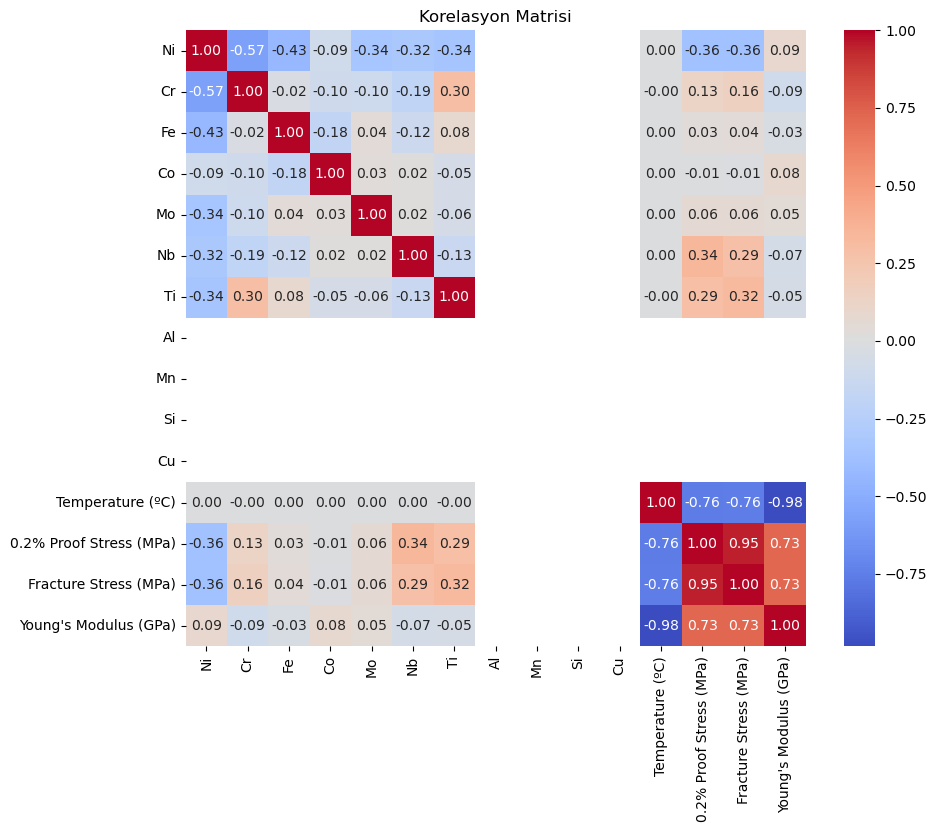

In [508]:
# Sadece sayısal sütunları seçtik
numerical_columns = df.select_dtypes(include=['float64', 'int64'])
korelasyon = numerical_columns.corr()

# Korelasyon matrisini görselleştirdik
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(korelasyon, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Korelasyon Matrisi")
plt.show()


In [510]:
df_cleaned = df.dropna(axis=1, how="all")

print("\nBoş sütunlar kaldırıldıktan sonra:")
print(df_cleaned)


Boş sütunlar kaldırıldıktan sonra:
       Ni  Cr  Fe  Co  Mo  Nb   Ti   Al  Mn   Si   Cu  Temperature (ºC)  \
0    67.0  22   5   0   0   1  2.5  0.5   1  0.5  0.5             920.0   
1    67.0  22   5   0   0   1  2.5  0.5   1  0.5  0.5             900.0   
2    67.0  22   5   0   0   1  2.5  0.5   1  0.5  0.5             880.0   
3    67.0  22   5   0   0   1  2.5  0.5   1  0.5  0.5             860.0   
4    67.0  22   5   0   0   1  2.5  0.5   1  0.5  0.5             840.0   
..    ...  ..  ..  ..  ..  ..  ...  ...  ..  ...  ...               ...   
995  64.0  14   9   0   3   5  2.5  0.5   1  0.5  0.5             620.0   
996  64.0  14   9   0   3   5  2.5  0.5   1  0.5  0.5             600.0   
997  64.0  14   9   0   3   5  2.5  0.5   1  0.5  0.5             580.0   
998  64.0  14   9   0   3   5  2.5  0.5   1  0.5  0.5             560.0   
999  64.0  14   9   0   3   5  2.5  0.5   1  0.5  0.5             540.0   

     0.2% Proof Stress (MPa)  Fracture Stress (MPa)  Young's Mo

In [512]:
print(df.isnull().sum())
print("Veri setinin eksik değerleri")


Ni                         0
Cr                         0
Fe                         0
Co                         0
Mo                         0
Nb                         0
Ti                         0
Al                         0
Mn                         0
Si                         0
Cu                         0
Temperature (ºC)           0
0.2% Proof Stress (MPa)    0
Fracture Stress (MPa)      0
Young's Modulus (GPa)      0
dtype: int64
Veri setinin eksik değerleri


In [514]:
df_cleaned = df.dropna()
print(df_cleaned)


       Ni  Cr  Fe  Co  Mo  Nb   Ti   Al  Mn   Si   Cu  Temperature (ºC)  \
0    67.0  22   5   0   0   1  2.5  0.5   1  0.5  0.5             920.0   
1    67.0  22   5   0   0   1  2.5  0.5   1  0.5  0.5             900.0   
2    67.0  22   5   0   0   1  2.5  0.5   1  0.5  0.5             880.0   
3    67.0  22   5   0   0   1  2.5  0.5   1  0.5  0.5             860.0   
4    67.0  22   5   0   0   1  2.5  0.5   1  0.5  0.5             840.0   
..    ...  ..  ..  ..  ..  ..  ...  ...  ..  ...  ...               ...   
995  64.0  14   9   0   3   5  2.5  0.5   1  0.5  0.5             620.0   
996  64.0  14   9   0   3   5  2.5  0.5   1  0.5  0.5             600.0   
997  64.0  14   9   0   3   5  2.5  0.5   1  0.5  0.5             580.0   
998  64.0  14   9   0   3   5  2.5  0.5   1  0.5  0.5             560.0   
999  64.0  14   9   0   3   5  2.5  0.5   1  0.5  0.5             540.0   

     0.2% Proof Stress (MPa)  Fracture Stress (MPa)  Young's Modulus (GPa)  
0                     

In [516]:
df_cleaned = df.dropna(axis=1)
print(df_cleaned)


       Ni  Cr  Fe  Co  Mo  Nb   Ti   Al  Mn   Si   Cu  Temperature (ºC)  \
0    67.0  22   5   0   0   1  2.5  0.5   1  0.5  0.5             920.0   
1    67.0  22   5   0   0   1  2.5  0.5   1  0.5  0.5             900.0   
2    67.0  22   5   0   0   1  2.5  0.5   1  0.5  0.5             880.0   
3    67.0  22   5   0   0   1  2.5  0.5   1  0.5  0.5             860.0   
4    67.0  22   5   0   0   1  2.5  0.5   1  0.5  0.5             840.0   
..    ...  ..  ..  ..  ..  ..  ...  ...  ..  ...  ...               ...   
995  64.0  14   9   0   3   5  2.5  0.5   1  0.5  0.5             620.0   
996  64.0  14   9   0   3   5  2.5  0.5   1  0.5  0.5             600.0   
997  64.0  14   9   0   3   5  2.5  0.5   1  0.5  0.5             580.0   
998  64.0  14   9   0   3   5  2.5  0.5   1  0.5  0.5             560.0   
999  64.0  14   9   0   3   5  2.5  0.5   1  0.5  0.5             540.0   

     0.2% Proof Stress (MPa)  Fracture Stress (MPa)  Young's Modulus (GPa)  
0                     

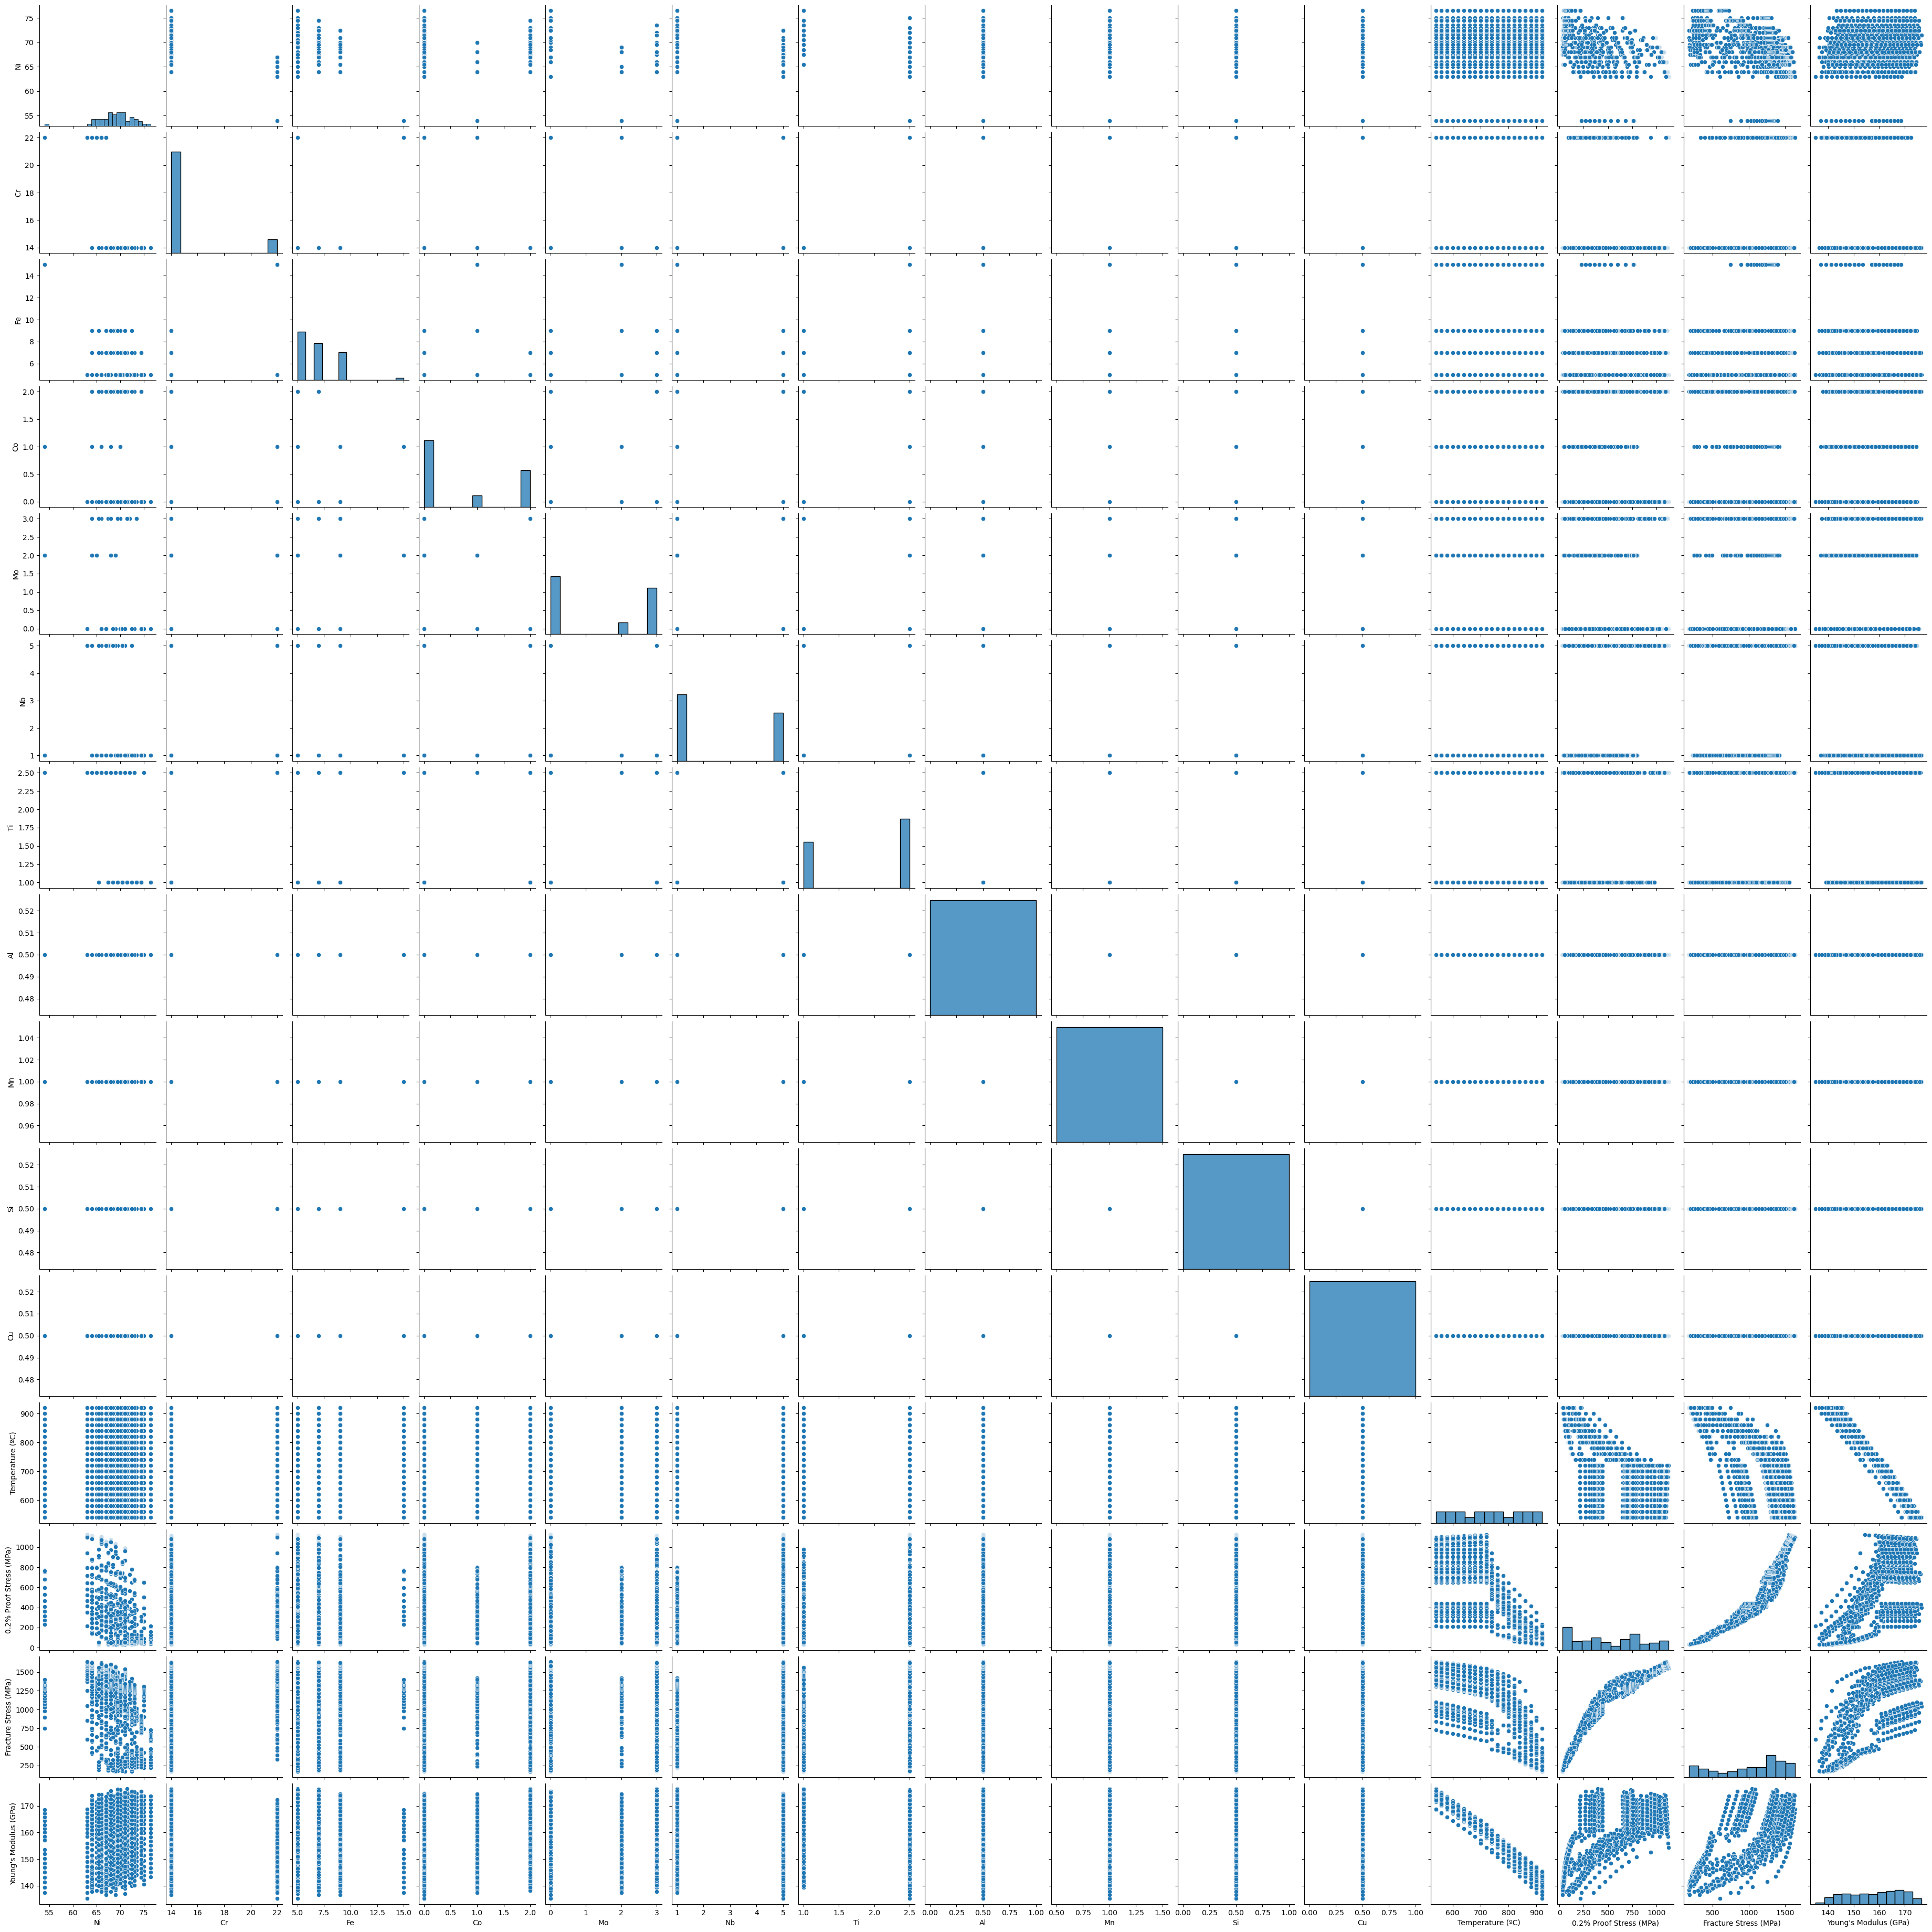

In [518]:
import matplotlib.pyplot as plt
sns.pairplot(df)
plt.show()

In [520]:

# veri setimizin %75'ini eğitime ayırırken kalanları teste ayıroyuruz.
#random_state=123 parametresi, veri bölmesinin her çalıştırmada aynı sonucu vermesini sağlar, böylece kodun yeniden çalıştırılmasında tutarlılık sağlanır.
X_train, X_test, y_train, y_test =train_test_split(X, y, test_size=0.25,random_state=123)

print("Eğitim ve test setimiz belirlendi")

Eğitim ve test setimiz belirlendi


In [522]:
print("Bizler KNN, RF ve ExtraTree yöntemlerini kullanıyoruz")
print("Oncelikle KNN için en iyi paremetreleri arıyoruz. CV=5 ve Grid Search ile parametre eniyilemesi")
###########################################
#burada KNN with Grid Search
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor  
from sklearn.metrics import mean_squared_error, r2_score 
# Hiperparametre ızgarası
param_grid = {
    'n_neighbors': [8, 15, 20, 35,40],      # Komşu sayısı
     # Mesafe metrikleri
    'p': [1,2]                           # Minkowski metriği için p değerleribiz mi verdik 1 2 yi
}

# KNN model
knn_model = KNeighborsRegressor()

# GridSearchCV
grid_search = GridSearchCV(
    estimator=knn_model,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',  # Performans metriği
    cv=5,                             # 5 katlı çapraz doğrulama                     
)

grid_search.fit(X_train, y_train)
# oncelikle buraya kadar calıstırıyoruz ve elde ettigimiz parametelere yeniden calisacagiz
# En iyi parametreler
print("KNN için en iyi parametreler:", grid_search.best_params_)



Bizler KNN, RF ve ExtraTree yöntemlerini kullanıyoruz
Oncelikle KNN için en iyi paremetreleri arıyoruz. CV=5 ve Grid Search ile parametre eniyilemesi
KNN için en iyi parametreler: {'n_neighbors': 40, 'p': 1}


In [524]:
## knn icin en iyi parametre olarak bulduklarımızı kullanacagız
print("simdi knn icin buldugumuz en iyi parametrelerle, eğitim ve test basarımızı MSE ve r2 uzerınden hesaplıyoruz")
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor

# KNN modelini en iyi parametrelerle oluşturuyoruz
knn = KNeighborsRegressor(n_neighbors=40, p=1)

# Eğitim verisini kullanarak modeli eğitiyoruz
knn.fit(X_train, y_train)

# Eğitim seti başarısı
y_train_pred = knn.predict(X_train)
train_mse = mean_squared_error(y_train, y_train_pred),
train_r2 = r2_score(y_train, y_train_pred)
print("Eğitim MSE:", train_mse)
print("Eğitim R²:", train_r2)

# Test seti başarısı
y_pred = knn.predict(X_test)
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)
print("Test MSE:", test_mse)
print("Test R²:", test_r2)


simdi knn icin buldugumuz en iyi parametrelerle, eğitim ve test basarımızı MSE ve r2 uzerınden hesaplıyoruz
Eğitim MSE: (5083.786314242409,)
Eğitim R²: 0.01867186027391088
Test MSE: 750.7070176442307
Test R²: -0.18483439608650865


In [526]:
print("RandomForest")


RandomForest


In [528]:
print("Oncelikle Rasgele Ormanlar Regresyonu için en iyi paremetreleri arıyoruz. CV=5 ve Grid Search ile parametre eniyilemesi")
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
param_grid = [
    {'bootstrap': [False,True], 'n_estimators': [2, 8], 'max_features': [1, 2, 3]},
  ]

forest_reg = RandomForestRegressor(random_state=123)
rfr_grid_search = GridSearchCV(forest_reg, param_grid, cv=5,
                           scoring='neg_mean_squared_error',
                           return_train_score=True)
rfr_grid_search.fit(X_train,y_train)

print("Random Forests için en iyi parametreler:", rfr_grid_search.best_params_)


Oncelikle Rasgele Ormanlar Regresyonu için en iyi paremetreleri arıyoruz. CV=5 ve Grid Search ile parametre eniyilemesi
Random Forests için en iyi parametreler: {'bootstrap': True, 'max_features': 2, 'n_estimators': 8}


In [529]:
## simdi RFR icin en iyi paraemtrelerle testlerimizi yapıyoruz 
print("simdi RFR icin buldugumuz en iyi parametrelerle, eğitim ve test basarımızı MSE ve r2 uzerınden hesaplıyoruz")
from sklearn.metrics import mean_squared_error, r2_score


# rfr modelini en iyi parametrelerle oluşturuyoruz
rfr = RandomForestRegressor(bootstrap=True, max_features=2, n_estimators=8)

# Eğitim verisini kullanarak modeli eğitiyoruz
rfr.fit(X_train, y_train)

# Eğitim seti başarısı
y_train_pred = rfr.predict(X_train)
train_mse = mean_squared_error(y_train, y_train_pred),
train_r2 = r2_score(y_train, y_train_pred)
print("Eğitim MSE:", train_mse)
print("Eğitim R²:", train_r2)

# Test seti başarısı
y_pred = rfr.predict(X_test)
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)
print("Test MSE:", test_mse)
print("Test R²:", test_r2)

simdi RFR icin buldugumuz en iyi parametrelerle, eğitim ve test basarımızı MSE ve r2 uzerınden hesaplıyoruz
Eğitim MSE: (1219.9104132785446,)
Eğitim R²: 0.7645195249176171
Test MSE: 1445.9042541159188
Test R²: -1.2820581844303933


In [532]:
print("Oncelikle ExtraTree Regresyonu için en iyi paremetreleri arıyoruz. CV=5 ve Grid Search ile parametre eniyilemesi")
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import ExtraTreesRegressor
param_grid = [
    {'n_estimators': [10,100], 'max_features': [1, 2, 3]},
 ]

ext_reg = ExtraTreesRegressor(random_state=123)
ext_grid_search = GridSearchCV(ext_reg, param_grid, cv=5,
                           scoring='neg_mean_squared_error',
                           return_train_score=True)
ext_grid_search.fit(X_train,y_train)

print("Exttra Tree  için en iyi parametreler:", ext_grid_search.best_params_)

Oncelikle ExtraTree Regresyonu için en iyi paremetreleri arıyoruz. CV=5 ve Grid Search ile parametre eniyilemesi
Exttra Tree  için en iyi parametreler: {'max_features': 3, 'n_estimators': 10}


In [533]:
## simdi Ext Tree icin en iyi paraemtrelerle testlerimizi yapıyoruz 

print("simdi Extra icin buldugumuz en iyi parametrelerle, eğitim ve test basarımızı MSE ve r2 uzerınden hesaplıyoruz")
from sklearn.metrics import mean_squared_error, r2_score
# ext modelini en iyi parametrelerle o=luşturuyoruz0
ext = ExtraTreesRegressor(max_features=2, n_estimators=100)

# Eğitim verisini kullanarak modeli eğitiyoruz
ext.fit(X_train, y_train)

# Eğitim seti başarısı
y_train_pred = ext.predict(X_train)
train_mse = mean_squared_error(y_train, y_train_pred),
train_r2 = r2_score(y_train, y_train_pred)
print("Eğitim MSE:", train_mse)
print("Eğitim R²:", train_r2)

# Test seti başarısı
y_pred = ext.predict(X_test)
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)
print("Test MSE:", test_mse)
print("Test R²:", test_r2)

simdi Extra icin buldugumuz en iyi parametrelerle, eğitim ve test basarımızı MSE ve r2 uzerınden hesaplıyoruz
Eğitim MSE: (0.41486506165374687,)
Eğitim R²: 0.9999199181999351
Test MSE: 1091.717625418961
Test R²: -0.7230484903010186
